Single-server queueing system
Mean interarrival time 1.0 minutes
Mean service time 0.5 minutes
Number of customers 1000
Average delay in queue 0.414 minutes
Average number in queue 0.402
Server utilization 0.476
Time simulation ended 1029.368 minutes


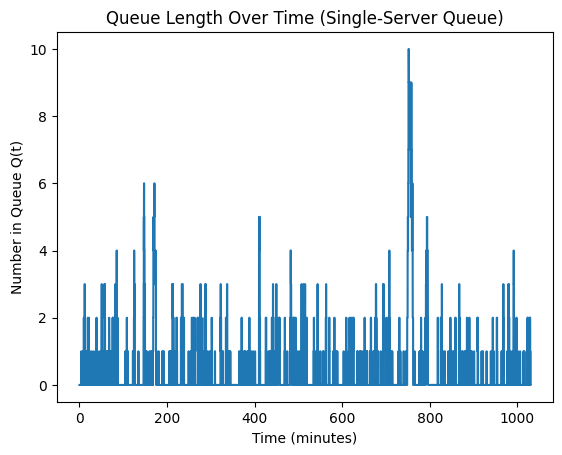

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


MEAN_INTERARRIVAL = 1.0   # minutes
MEAN_SERVICE = 0.5        # minutes
N_CUSTOMERS = 1000


clock = 0.0
server_busy = False
queue = []

area_Q = 0.0
area_B = 0.0
total_delay = 0.0

customers_started_service = 0

next_arrival = np.random.exponential(MEAN_INTERARRIVAL)
next_departure = float("inf")

# For plotting Q(t)
time_points = [0.0]
queue_lengths = [0]


while customers_started_service < N_CUSTOMERS:

    next_event_time = min(next_arrival, next_departure)

    area_Q += len(queue) * (next_event_time - clock)
    area_B += (1 if server_busy else 0) * (next_event_time - clock)

    clock = next_event_time

    # -------- Arrival event --------
    if next_arrival <= next_departure:
        if not server_busy:
            server_busy = True
            service_time = np.random.exponential(MEAN_SERVICE)
            next_departure = clock + service_time
        else:
            queue.append(clock)

        next_arrival = clock + np.random.exponential(MEAN_INTERARRIVAL)

    # -------- Departure event --------
    else:
        customers_started_service += 1

        if queue:
            arrival_time = queue.pop(0)
            total_delay += clock - arrival_time

            service_time = np.random.exponential(MEAN_SERVICE)
            next_departure = clock + service_time
        else:
            server_busy = False
            next_departure = float("inf")

    # Store values for plot
    time_points.append(clock)
    queue_lengths.append(len(queue))


avg_delay = total_delay / N_CUSTOMERS
avg_queue = area_Q / clock
utilization = area_B / clock
end_time = clock

print("Single-server queueing system")
print("Mean interarrival time", MEAN_INTERARRIVAL, "minutes")
print("Mean service time", MEAN_SERVICE, "minutes")
print("Number of customers", N_CUSTOMERS)
print("Average delay in queue", round(avg_delay, 3), "minutes")
print("Average number in queue", round(avg_queue, 3))
print("Server utilization", round(utilization, 3))
print("Time simulation ended", round(end_time, 3), "minutes")


plt.figure()
plt.step(time_points, queue_lengths, where="post")
plt.xlabel("Time (minutes)")
plt.ylabel("Number in Queue Q(t)")
plt.title("Queue Length Over Time (Single-Server Queue)")
plt.show()
